In [1]:
import os
import random
from tqdm.auto import tqdm

# Data manipulation and visualization
import matplotlib.pyplot as plt
from PIL import Image
import seaborn as sns
import pandas as pd
import numpy as np

# Deep Learning libraries
import torch
import torchvision
import torchsummary
from torch.utils import data
from torch.utils.data import DataLoader
import torch.nn as nn
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.utils import resample
from torch.optim.lr_scheduler import ReduceLROnPlateau


In [2]:
# Set seed for reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)


In [3]:
import sys
sys.path.append('/Users/shiwaditya./Desktop/LULC/')

from resisc45_dataset import RESISC45

In [4]:
# Define the dataset directory
data_dir = 'RESISC45_NEW/'
dataset = datasets.ImageFolder(data_dir)

# Get LULC categories
class_names = dataset.classes
print("Class names: {}".format(class_names))
print("Total number of classes: {}".format(len(class_names)))

Class names: ['airport', 'beach', 'bridge', 'circular_farmland', 'cloud', 'commercial_area', 'dense_residential', 'desert', 'forest', 'freeway', 'harbor', 'industrial_area', 'intersection', 'lake', 'meadow', 'medium_residential', 'mountain', 'overpass', 'railway', 'railway_station', 'rectangular_farmland', 'river', 'road', 'snowberg', 'sparse_residential', 'terrace', 'thermal_power_station', 'wetland']
Total number of classes: 28


In [5]:
# Check if .DS_Store exists and delete it if it does
ds_store_path = os.path.join(data_dir, '.DS_Store')
if os.path.exists(ds_store_path):
    os.unlink(ds_store_path)  # Completely delete the file

# Initialize a dictionary to store the count of images for each class
class_counts = {}

# Iterate over the directories (classes) in the dataset directory
for class_name in os.listdir(data_dir):
    # Construct the full path of the class directory
    class_dir = os.path.join(data_dir, class_name)

    # Count the number of images in the class directory
    num_images = len([f for f in os.listdir(class_dir) if os.path.isfile(os.path.join(class_dir, f))])

    # Store the count in the dictionary
    class_counts[class_name] = num_images

# Print the total number of images for each class
for class_name, count in class_counts.items():
    print(f"Class '{class_name}': {count} images")

Class 'forest': 50 images
Class 'railway_station': 50 images
Class 'river': 50 images
Class 'harbor': 50 images
Class 'terrace': 50 images
Class 'thermal_power_station': 50 images
Class 'bridge': 50 images
Class 'industrial_area': 50 images
Class 'overpass': 50 images
Class 'road': 50 images
Class 'railway': 50 images
Class 'medium_residential': 50 images
Class 'intersection': 50 images
Class 'lake': 50 images
Class 'cloud': 50 images
Class 'sparse_residential': 50 images
Class 'airport': 50 images
Class 'snowberg': 50 images
Class 'commercial_area': 50 images
Class 'rectangular_farmland': 50 images
Class 'beach': 50 images
Class 'circular_farmland': 50 images
Class 'dense_residential': 50 images
Class 'mountain': 50 images
Class 'desert': 50 images
Class 'freeway': 50 images
Class 'meadow': 50 images
Class 'wetland': 50 images


In [6]:
# Initialize transformations
input_size = 224
imagenet_mean, imagenet_std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(input_size),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

test_transform = transforms.Compose([
    transforms.Resize(input_size),
    transforms.CenterCrop(input_size),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])


In [7]:
def accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim=1)
    return torch.sum(preds == labels.data).double() / len(labels)

def train_and_save_model(train_dataset, test_dataset, model_path):
    # Define the model, loss, optimizer, and metrics
    model = models.resnet18(pretrained=True)
    num_ftrs = model.fc.in_features
    model.fc = torch.nn.Linear(num_ftrs, len(dataset.classes))

    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    accuracy_metric = accuracy  # Use the custom accuracy function

    # Training and evaluation loop
    num_epochs = 20
    batch_size = 5

    train_losses, train_accs = [], []
    test_losses, test_accs = [], []

    for epoch in range(num_epochs):
        # Create a data loader for the training dataset
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

        with tqdm(train_loader, desc=f"Epoch {epoch + 1}/{num_epochs}", unit="batch", leave=False) as train_pbar:
            # Initialize variables to track progress within the epoch
            running_loss = 0.0
            running_corrects = 0

            # Data loader loop
            for inputs, labels in train_pbar:
                # Move data to the appropriate device
                inputs, labels = inputs.to(device), labels.to(device)

                # Reset gradients
                optimizer.zero_grad()

                # Forward pass
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                # Backward pass and optimizer step
                loss.backward()
                optimizer.step()

                # Update running loss and accuracy
                running_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                running_corrects += torch.sum(preds == labels.data)

                # Update the progress bar with the current batch loss
                train_pbar.set_postfix(loss=loss.item())

            # Calculate epoch loss and accuracy
            epoch_loss = running_loss / len(train_dataset)
            epoch_accuracy = running_corrects.double() / len(train_dataset)

            # Update training metrics
            train_losses.append(epoch_loss)
            train_accs.append(epoch_accuracy)

            print(f'Epoch {epoch + 1}/{num_epochs} Loss: {epoch_loss:.4f} Acc: {epoch_accuracy:.4f}')

            # Evaluate on test set
            test_epoch_loss, test_epoch_acc = eval_model(test_dataset, model, criterion, batch_size, device, accuracy_metric)
            test_losses.append(test_epoch_loss)
            test_accs.append(test_epoch_acc)

        # Save the trained model
        torch.save(model.state_dict(), model_path)

    # Plot training and test loss and accuracy curves (after training)
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))

    axs[0].plot(range(1, num_epochs + 1), train_losses, label='Train Loss')
    axs[0].plot(range(1, num_epochs + 1), test_losses, label='Validation Loss')
    axs[0].set_title('Loss Curves')
    axs[0].set_xlabel('Epoch')
    axs[0].set_ylabel('Loss')
    axs[0].legend()
    
    axs[1].plot(range(1, num_epochs + 1), train_accs, label='Train Accuracy')
    axs[1].plot(range(1, num_epochs + 1), test_accs, label='Validation Accuracy')
    axs[1].set_title('Accuracy Curves')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Accuracy')
    axs[1].legend()

    plt.tight_layout()
    plt.show()

    return model, train_accs, test_accs, train_losses, test_losses

def train_epoch(dataset, model, criterion, optimizer, batch_size, device):
    model.train()
    train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    running_loss = 0.0
    running_acc = 0.0

    for inputs, labels in tqdm(train_loader, desc="Training", leave=False):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        acc = accuracy(outputs, labels)
        running_acc += acc * inputs.size(0)

    epoch_loss = running_loss / len(dataset)
    epoch_acc = running_acc / len(dataset)

    return epoch_loss, epoch_acc

def eval_model(dataset, model, criterion, batch_size, device, metric_fn=None):
    model.eval()
    eval_loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    running_loss = 0.0
    running_metric = 0.0

    with torch.no_grad():
        for inputs, labels in tqdm(eval_loader, desc="Evaluating", leave=False):
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            if metric_fn is not None:
                running_metric += metric_fn(outputs, labels) * inputs.size(0)

    epoch_loss = running_loss / len(dataset)
    epoch_metric = running_metric / len(dataset) if metric_fn is not None else 0.0

    return epoch_loss, epoch_metric

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


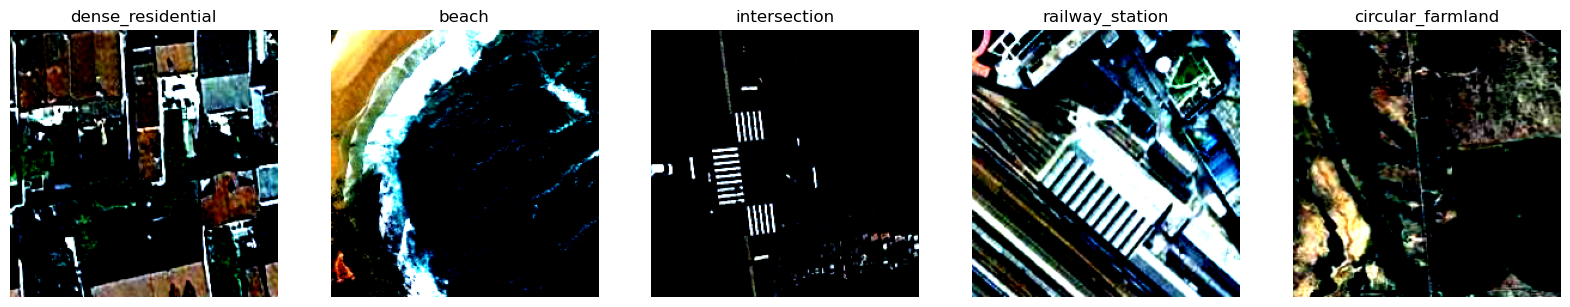

Training Set:
Class 'airport': 40 images
Class 'beach': 40 images
Class 'bridge': 40 images
Class 'circular_farmland': 40 images
Class 'cloud': 40 images
Class 'commercial_area': 40 images
Class 'dense_residential': 40 images
Class 'desert': 40 images
Class 'forest': 40 images
Class 'freeway': 40 images
Class 'harbor': 40 images
Class 'industrial_area': 40 images
Class 'intersection': 40 images
Class 'lake': 40 images
Class 'meadow': 40 images
Class 'medium_residential': 40 images
Class 'mountain': 40 images
Class 'overpass': 40 images
Class 'railway': 40 images
Class 'railway_station': 40 images
Class 'rectangular_farmland': 40 images
Class 'river': 40 images
Class 'road': 40 images
Class 'snowberg': 40 images
Class 'sparse_residential': 40 images
Class 'terrace': 40 images
Class 'thermal_power_station': 40 images
Class 'wetland': 40 images

Testing Set:
Class 'airport': 10 images
Class 'beach': 10 images
Class 'bridge': 10 images
Class 'circular_farmland': 10 images
Class 'cloud': 10

/Users/shiwaditya./anaconda3/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/shiwaditya./anaconda3/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/20:   0%|          | 0/224 [00:00<?, ?batch/s]

Epoch 1/20 Loss: 3.3614 Acc: 0.1054


Evaluating:   0%|          | 0/56 [00:00<?, ?it/s]

...

Epoch 19/20 Loss: 2.8528 Acc: 0.1652


Evaluating:   0%|          | 0/56 [00:00<?, ?it/s]

Epoch 20/20:   0%|          | 0/224 [00:00<?, ?batch/s]

Epoch 20/20 Loss: 2.8540 Acc: 0.1437


Evaluating:   0%|          | 0/56 [00:00<?, ?it/s]

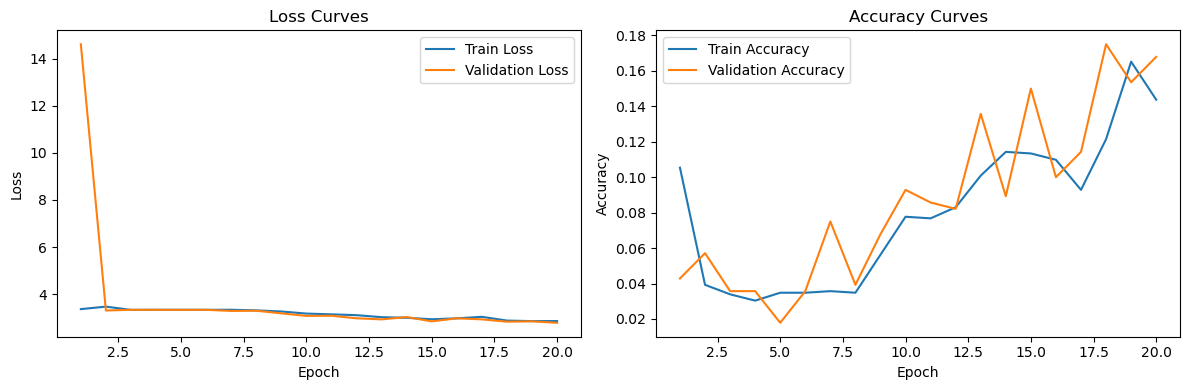

In [8]:
# Holdout method (0.8:0.2 ratio)
# Get the labels from the dataset
labels = [label for _, label in dataset.imgs]

# Perform stratified train-test split
train_indices, test_indices, _, _ = train_test_split(
    range(len(dataset.imgs)), labels, test_size=0.2, stratify=labels, random_state=SEED
)

# Create the subsets
train_subset = Subset(dataset, train_indices)
test_subset = Subset(dataset, test_indices)

# Apply the transformations to the subsets
train_dataset = RESISC45(train_subset, transform=train_transform)
test_dataset = RESISC45(test_subset, transform=test_transform)

# Visualize sample images
fig, axs = plt.subplots(1, 5, figsize=(20, 5))
for i, ax in enumerate(axs):
    idx = random.randint(0, len(train_dataset))
    img, label = train_dataset[idx]
    ax.imshow(img.permute(1, 2, 0))
    ax.set_title(dataset.classes[label])
    ax.axis('off')
plt.show()

# Print the counts of images for each class in the training and testing sets
train_class_counts = {c: 0 for c in dataset.classes}
test_class_counts = {c: 0 for c in dataset.classes}

for img, label in train_dataset:
    train_class_counts[dataset.classes[label]] += 1

for img, label in test_dataset:
    test_class_counts[dataset.classes[label]] += 1

print("Training Set:")
for class_name, count in train_class_counts.items():
    print(f"Class '{class_name}': {count} images")

print("\nTesting Set:")
for class_name, count in test_class_counts.items():
    print(f"Class '{class_name}': {count} images")

# Create the directory if it doesn't exist
model_dir = 'MODELS'
os.makedirs(model_dir, exist_ok=True)

# Train and save the holdout model
model_path = os.path.join(model_dir, 'holdout_model3.pth')
holdout_model, holdout_train_accs, holdout_test_accs, holdout_train_losses, holdout_test_losses = train_and_save_model(train_dataset, test_dataset, model_path)


Fold 1


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


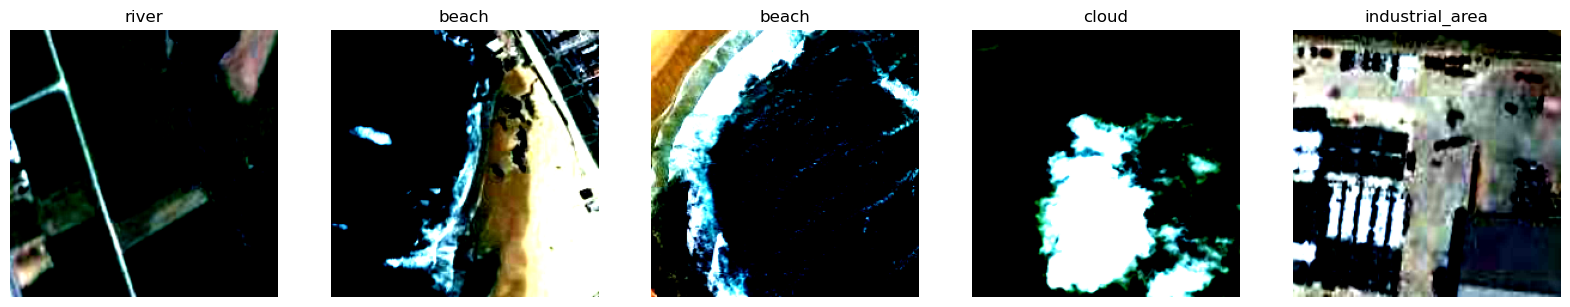

Training Set:
Class 'airport': 40 images
Class 'beach': 40 images
Class 'bridge': 40 images
Class 'circular_farmland': 40 images
Class 'cloud': 40 images
Class 'commercial_area': 40 images
Class 'dense_residential': 40 images
Class 'desert': 40 images
Class 'forest': 40 images
Class 'freeway': 40 images
Class 'harbor': 40 images
Class 'industrial_area': 40 images
Class 'intersection': 40 images
Class 'lake': 40 images
Class 'meadow': 40 images
Class 'medium_residential': 40 images
Class 'mountain': 40 images
Class 'overpass': 40 images
Class 'railway': 40 images
Class 'railway_station': 40 images
Class 'rectangular_farmland': 40 images
Class 'river': 40 images
Class 'road': 40 images
Class 'snowberg': 40 images
Class 'sparse_residential': 40 images
Class 'terrace': 40 images
Class 'thermal_power_station': 40 images
Class 'wetland': 40 images

Testing Set:
Class 'airport': 10 images
Class 'beach': 10 images
Class 'bridge': 10 images
Class 'circular_farmland': 10 images
Class 'cloud': 10

/Users/shiwaditya./anaconda3/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/shiwaditya./anaconda3/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/20:   0%|          | 0/224 [00:00<?, ?batch/s]

Epoch 1/20 Loss: 3.4517 Acc: 0.0920


Evaluating:   0%|          | 0/56 [00:00<?, ?it/s]

...

Epoch 19/20 Loss: 2.1035 Acc: 0.3250


Evaluating:   0%|          | 0/56 [00:00<?, ?it/s]

Epoch 20/20:   0%|          | 0/224 [00:00<?, ?batch/s]

Epoch 20/20 Loss: 2.0564 Acc: 0.3411


Evaluating:   0%|          | 0/56 [00:00<?, ?it/s]

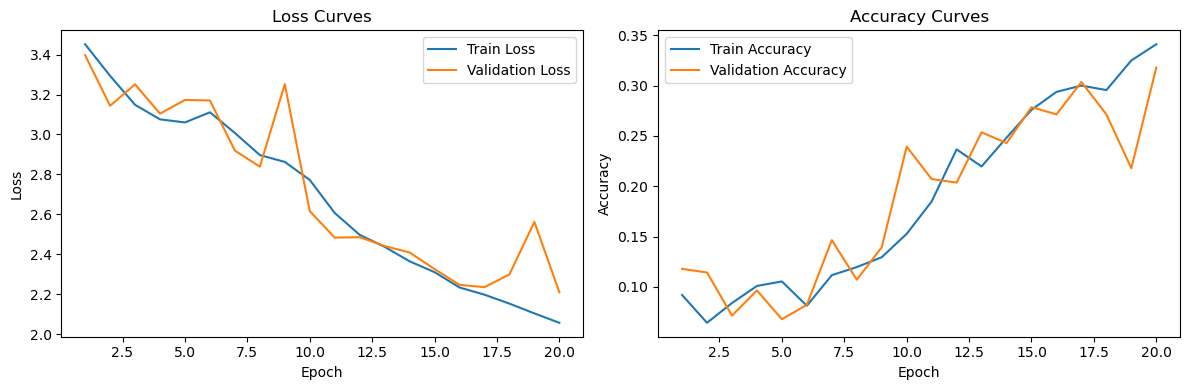

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Fold 1 Accuracy: 0.3179, Loss: 2.2092
Fold 2


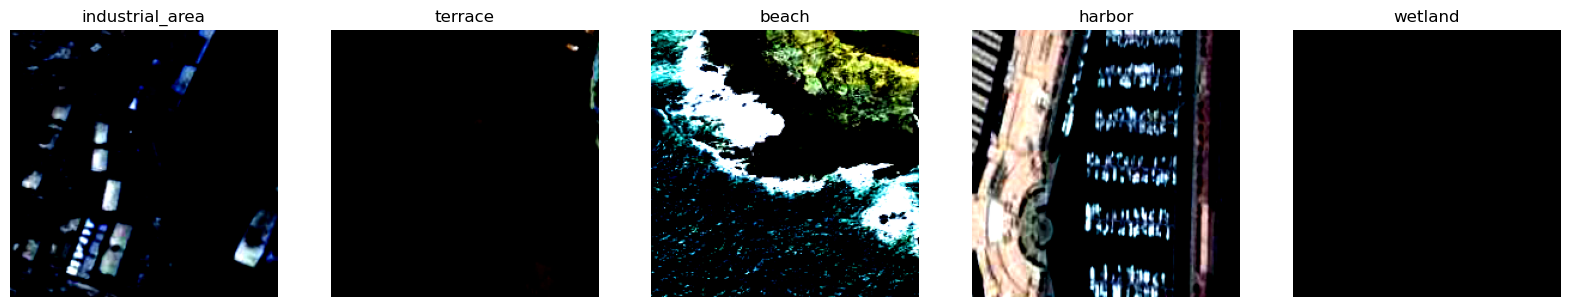

Training Set:
Class 'airport': 40 images
Class 'beach': 40 images
Class 'bridge': 40 images
Class 'circular_farmland': 40 images
Class 'cloud': 40 images
Class 'commercial_area': 40 images
Class 'dense_residential': 40 images
Class 'desert': 40 images
Class 'forest': 40 images
Class 'freeway': 40 images
Class 'harbor': 40 images
Class 'industrial_area': 40 images
Class 'intersection': 40 images
Class 'lake': 40 images
Class 'meadow': 40 images
Class 'medium_residential': 40 images
Class 'mountain': 40 images
Class 'overpass': 40 images
Class 'railway': 40 images
Class 'railway_station': 40 images
Class 'rectangular_farmland': 40 images
Class 'river': 40 images
Class 'road': 40 images
Class 'snowberg': 40 images
Class 'sparse_residential': 40 images
Class 'terrace': 40 images
Class 'thermal_power_station': 40 images
Class 'wetland': 40 images

Testing Set:
Class 'airport': 10 images
Class 'beach': 10 images
Class 'bridge': 10 images
Class 'circular_farmland': 10 images
Class 'cloud': 10

Epoch 1/20:   0%|          | 0/224 [00:00<?, ?batch/s]

Epoch 1/20 Loss: 3.3469 Acc: 0.0902


Evaluating:   0%|          | 0/56 [00:00<?, ?it/s]

Epoch 2/20:   0%|          | 0/224 [00:00<?, ?batch/s]

...

Epoch 19/20 Loss: 2.0012 Acc: 0.3616


Evaluating:   0%|          | 0/56 [00:00<?, ?it/s]

Epoch 20/20:   0%|          | 0/224 [00:00<?, ?batch/s]

Epoch 20/20 Loss: 1.8796 Acc: 0.3982


Evaluating:   0%|          | 0/56 [00:00<?, ?it/s]

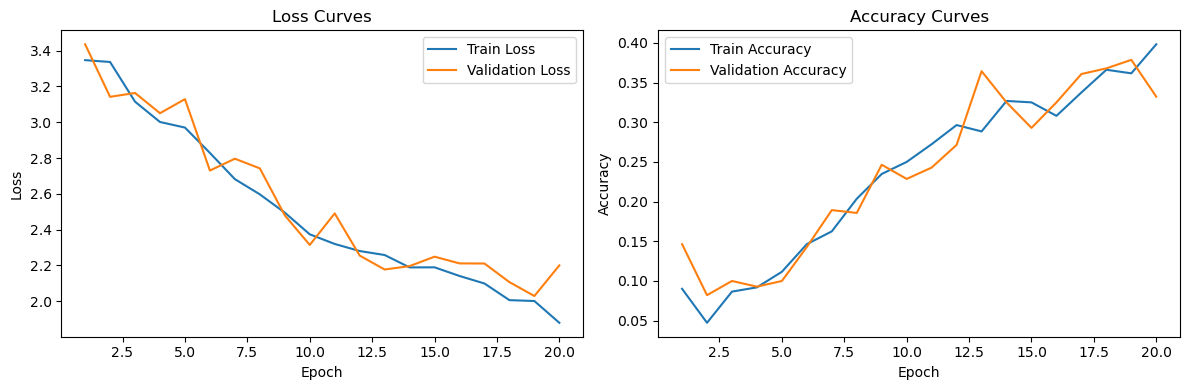

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Fold 2 Accuracy: 0.3321, Loss: 2.2003
Fold 3


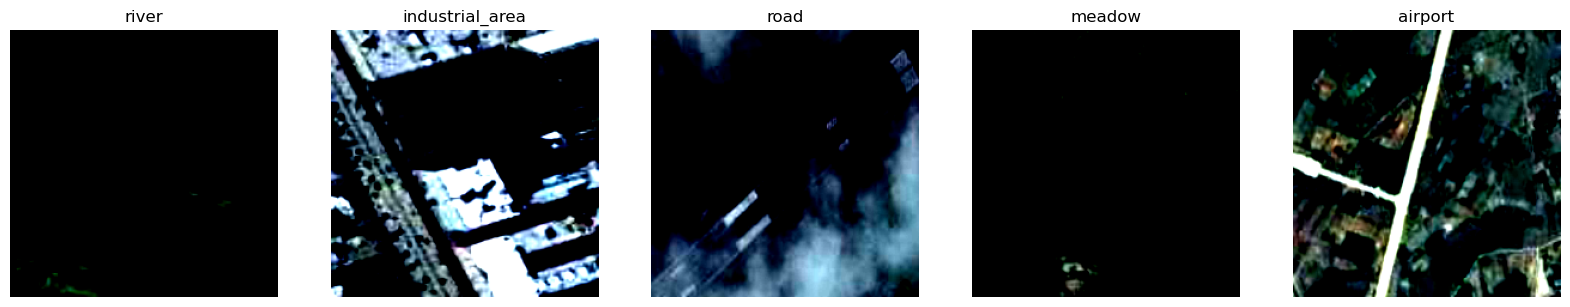

Training Set:
Class 'airport': 40 images
Class 'beach': 40 images
Class 'bridge': 40 images
Class 'circular_farmland': 40 images
Class 'cloud': 40 images
Class 'commercial_area': 40 images
Class 'dense_residential': 40 images
Class 'desert': 40 images
Class 'forest': 40 images
Class 'freeway': 40 images
Class 'harbor': 40 images
Class 'industrial_area': 40 images
Class 'intersection': 40 images
Class 'lake': 40 images
Class 'meadow': 40 images
Class 'medium_residential': 40 images
Class 'mountain': 40 images
Class 'overpass': 40 images
Class 'railway': 40 images
Class 'railway_station': 40 images
Class 'rectangular_farmland': 40 images
Class 'river': 40 images
Class 'road': 40 images
Class 'snowberg': 40 images
Class 'sparse_residential': 40 images
Class 'terrace': 40 images
Class 'thermal_power_station': 40 images
Class 'wetland': 40 images

Testing Set:
Class 'airport': 10 images
Class 'beach': 10 images
Class 'bridge': 10 images
Class 'circular_farmland': 10 images
Class 'cloud': 10

Epoch 1/20:   0%|          | 0/224 [00:00<?, ?batch/s]

Epoch 1/20 Loss: 3.2952 Acc: 0.1062


Evaluating:   0%|          | 0/56 [00:00<?, ?it/s]

Epoch 2/20:   0%|          | 0/224 [00:00<?, ?batch/s]

...

Epoch 19/20 Loss: 2.1472 Acc: 0.3071


Evaluating:   0%|          | 0/56 [00:00<?, ?it/s]

Epoch 20/20:   0%|          | 0/224 [00:00<?, ?batch/s]

Epoch 20/20 Loss: 2.1300 Acc: 0.3295


Evaluating:   0%|          | 0/56 [00:00<?, ?it/s]

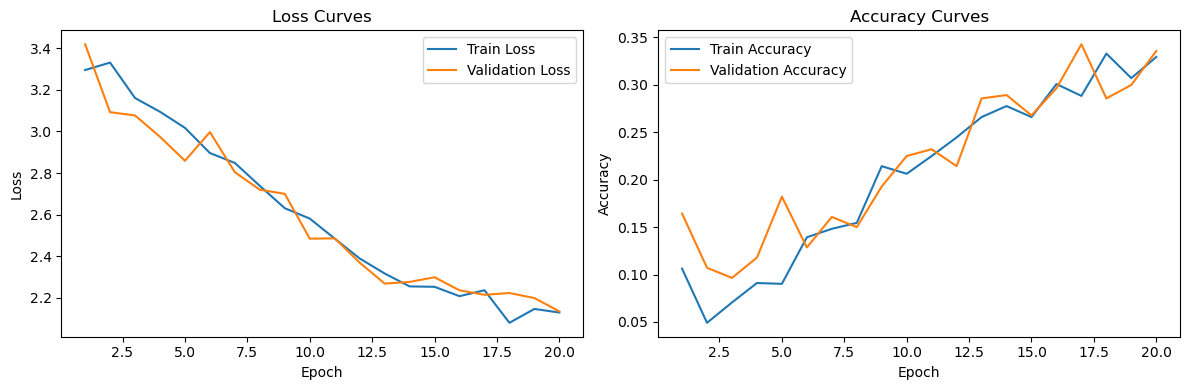

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Fold 3 Accuracy: 0.3357, Loss: 2.1355
Fold 4


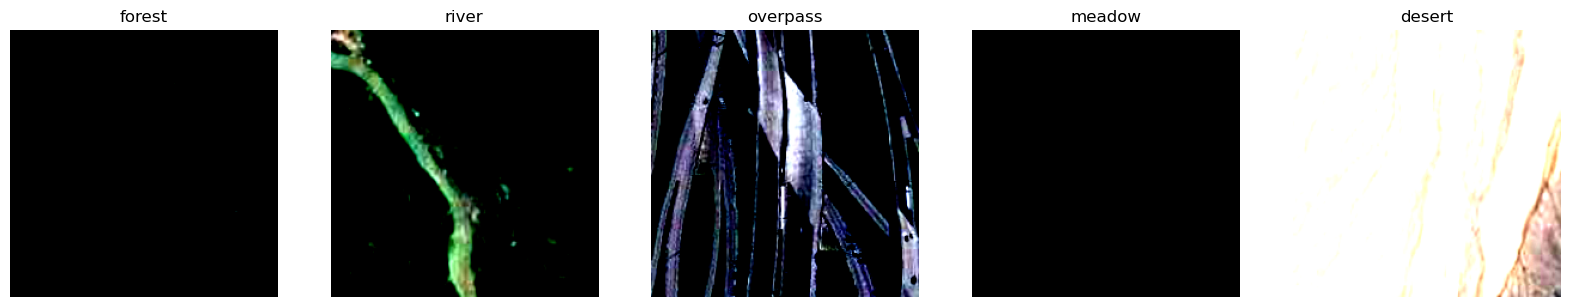

Training Set:
Class 'airport': 40 images
Class 'beach': 40 images
Class 'bridge': 40 images
Class 'circular_farmland': 40 images
Class 'cloud': 40 images
Class 'commercial_area': 40 images
Class 'dense_residential': 40 images
Class 'desert': 40 images
Class 'forest': 40 images
Class 'freeway': 40 images
Class 'harbor': 40 images
Class 'industrial_area': 40 images
Class 'intersection': 40 images
Class 'lake': 40 images
Class 'meadow': 40 images
Class 'medium_residential': 40 images
Class 'mountain': 40 images
Class 'overpass': 40 images
Class 'railway': 40 images
Class 'railway_station': 40 images
Class 'rectangular_farmland': 40 images
Class 'river': 40 images
Class 'road': 40 images
Class 'snowberg': 40 images
Class 'sparse_residential': 40 images
Class 'terrace': 40 images
Class 'thermal_power_station': 40 images
Class 'wetland': 40 images

Testing Set:
Class 'airport': 10 images
Class 'beach': 10 images
Class 'bridge': 10 images
Class 'circular_farmland': 10 images
Class 'cloud': 10

Epoch 1/20:   0%|          | 0/224 [00:00<?, ?batch/s]

Epoch 1/20 Loss: 3.3824 Acc: 0.0857


Evaluating:   0%|          | 0/56 [00:00<?, ?it/s]

Epoch 2/20:   0%|          | 0/224 [00:00<?, ?batch/s]

...

Epoch 19/20 Loss: 1.9775 Acc: 0.3705


Evaluating:   0%|          | 0/56 [00:00<?, ?it/s]

Epoch 20/20:   0%|          | 0/224 [00:00<?, ?batch/s]

Epoch 20/20 Loss: 1.9570 Acc: 0.3866


Evaluating:   0%|          | 0/56 [00:00<?, ?it/s]

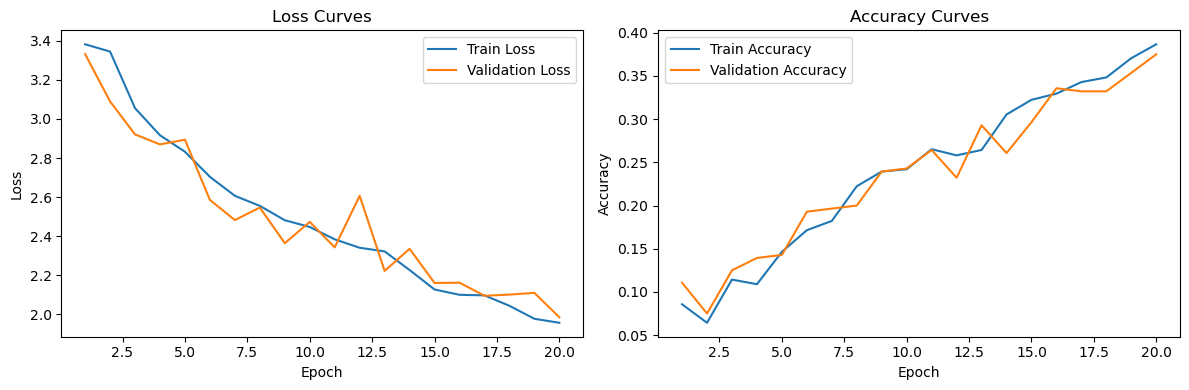

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Fold 4 Accuracy: 0.3750, Loss: 1.9852
Fold 5


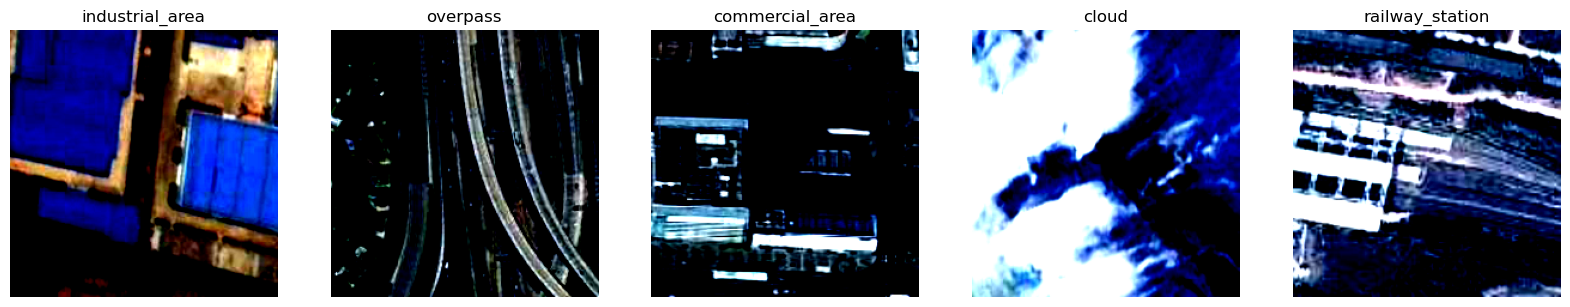

Training Set:
Class 'airport': 40 images
Class 'beach': 40 images
Class 'bridge': 40 images
Class 'circular_farmland': 40 images
Class 'cloud': 40 images
Class 'commercial_area': 40 images
Class 'dense_residential': 40 images
Class 'desert': 40 images
Class 'forest': 40 images
Class 'freeway': 40 images
Class 'harbor': 40 images
Class 'industrial_area': 40 images
Class 'intersection': 40 images
Class 'lake': 40 images
Class 'meadow': 40 images
Class 'medium_residential': 40 images
Class 'mountain': 40 images
Class 'overpass': 40 images
Class 'railway': 40 images
Class 'railway_station': 40 images
Class 'rectangular_farmland': 40 images
Class 'river': 40 images
Class 'road': 40 images
Class 'snowberg': 40 images
Class 'sparse_residential': 40 images
Class 'terrace': 40 images
Class 'thermal_power_station': 40 images
Class 'wetland': 40 images

Testing Set:
Class 'airport': 10 images
Class 'beach': 10 images
Class 'bridge': 10 images
Class 'circular_farmland': 10 images
Class 'cloud': 10

Epoch 1/20:   0%|          | 0/224 [00:00<?, ?batch/s]

Epoch 1/20 Loss: 3.3162 Acc: 0.1080


Evaluating:   0%|          | 0/56 [00:00<?, ?it/s]

Epoch 2/20:   0%|          | 0/224 [00:00<?, ?batch/s]

...

Epoch 19/20 Loss: 2.4689 Acc: 0.2277


Evaluating:   0%|          | 0/56 [00:00<?, ?it/s]

Epoch 20/20:   0%|          | 0/224 [00:00<?, ?batch/s]

Epoch 20/20 Loss: 2.4245 Acc: 0.2473


Evaluating:   0%|          | 0/56 [00:00<?, ?it/s]

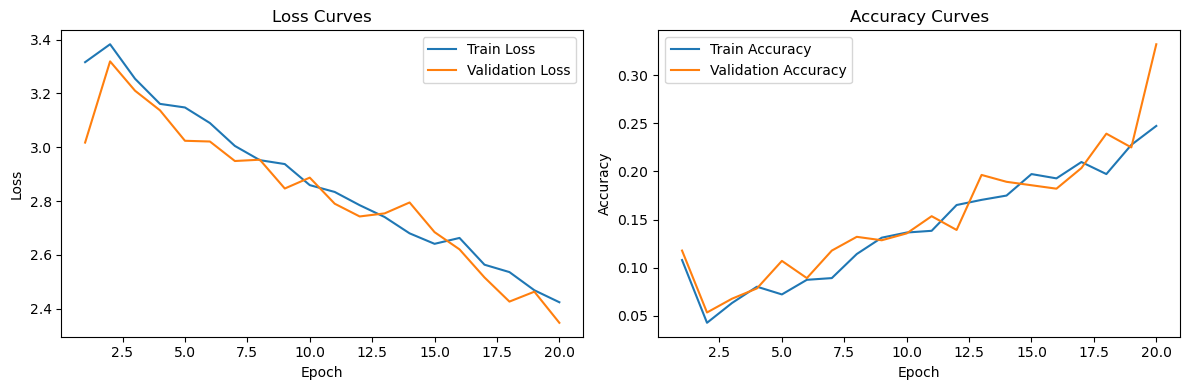

Fold 5 Accuracy: 0.3321, Loss: 2.3482
Mean K-fold Cross-Validation Accuracy: 0.2071, Loss: 2.6370


In [13]:
# 2. K-fold Cross-Validation
num_folds = 5
kfold = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=SEED)

kfold_models = []
kfold_train_accs = []
kfold_test_accs = []
kfold_train_losses = []
kfold_test_losses = []

# Define the criterion
criterion = torch.nn.CrossEntropyLoss()

for fold, (train_ids, test_ids) in enumerate(kfold.split(np.zeros(len(dataset)), dataset.targets)):
    print(f'Fold {fold + 1}')
    train_subset = Subset(dataset, train_ids)
    test_subset = Subset(dataset, test_ids)

    # Apply the transformations to the subsets
    train_dataset = RESISC45(train_subset, transform=train_transform)
    test_dataset = RESISC45(test_subset, transform=test_transform)

    # Visualize sample images
    fig, axs = plt.subplots(1, 5, figsize=(20, 5))
    for i, ax in enumerate(axs):
        idx = random.randint(0, len(train_dataset) - 1)
        img, label = train_dataset[idx]
        ax.imshow(img.permute(1, 2, 0))
        ax.set_title(dataset.classes[label])
        ax.axis('off')
    plt.show()

    # Print the counts of images for each class in the training and testing sets
    train_class_counts = {c: 0 for c in dataset.classes}
    test_class_counts = {c: 0 for c in dataset.classes}

    for img, label in train_dataset:
        train_class_counts[dataset.classes[label]] += 1

    for img, label in test_dataset:
        test_class_counts[dataset.classes[label]] += 1

    print("Training Set:")
    for class_name, count in train_class_counts.items():
        print(f"Class '{class_name}': {count} images")

    print("\nTesting Set:")
    for class_name, count in test_class_counts.items():
        print(f"Class '{class_name}': {count} images")

    # Train and save the model
    model_path = os.path.join(model_dir, f'kfold_model3_fold{fold + 1}.pth')
    model, train_accs, test_accs, train_losses, test_losses = train_and_save_model(train_dataset, test_dataset, model_path)
    kfold_models.append(model)
    kfold_train_accs.append(train_accs)
    kfold_test_accs.append(test_accs)
    kfold_train_losses.append(train_losses)
    kfold_test_losses.append(test_losses)

    batch_size = 5
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

    # Evaluate the model on the test set and store the accuracy and loss
    test_acc = test_accs[-1]
    test_loss = test_losses[-1]
    train_acc = train_accs[-1]
    train_loss = train_losses[-1]

    print(f"Fold {fold + 1} Accuracy: {test_acc:.4f}, Loss: {test_loss:.4f}")

# Calculate the mean accuracy and loss across all folds
flatten_kfold_test_accs = [acc for sublist in kfold_test_accs for acc in sublist]
flatten_kfold_test_losses = [loss for sublist in kfold_test_losses for loss in sublist]

mean_kfold_accuracy = sum(flatten_kfold_test_accs) / len(flatten_kfold_test_accs)
mean_kfold_loss = sum(flatten_kfold_test_losses) / len(flatten_kfold_test_losses)
print(f"Mean K-fold Cross-Validation Accuracy: {mean_kfold_accuracy:.4f}, Loss: {mean_kfold_loss:.4f}")

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


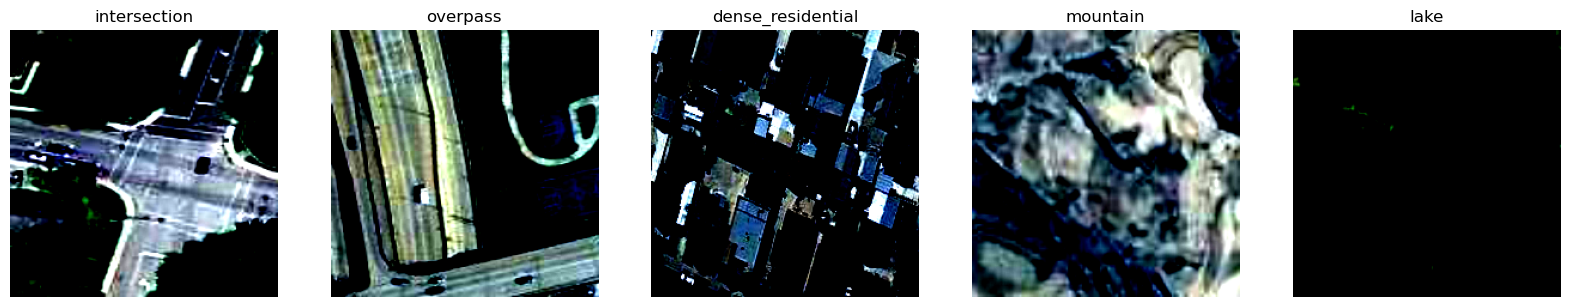

Training Set:
Class 'airport': 62 images
Class 'beach': 55 images
Class 'bridge': 53 images
Class 'circular_farmland': 45 images
Class 'cloud': 45 images
Class 'commercial_area': 35 images
Class 'dense_residential': 41 images
Class 'desert': 38 images
Class 'forest': 36 images
Class 'freeway': 48 images
Class 'harbor': 46 images
Class 'industrial_area': 39 images
Class 'intersection': 45 images
Class 'lake': 58 images
Class 'meadow': 54 images
Class 'medium_residential': 62 images
Class 'mountain': 59 images
Class 'overpass': 56 images
Class 'railway': 42 images
Class 'railway_station': 52 images
Class 'rectangular_farmland': 59 images
Class 'river': 51 images
Class 'road': 53 images
Class 'snowberg': 50 images
Class 'sparse_residential': 54 images
Class 'terrace': 54 images
Class 'thermal_power_station': 58 images
Class 'wetland': 50 images

Testing Set:
Class 'airport': 50 images
Class 'beach': 50 images
Class 'bridge': 50 images
Class 'circular_farmland': 50 images
Class 'cloud': 50

Epoch 1/20:   0%|          | 0/280 [00:00<?, ?batch/s]

Epoch 1/20 Loss: 3.3613 Acc: 0.0971


Evaluating:   0%|          | 0/280 [00:00<?, ?it/s]

Epoch 2/20:   0%|          | 0/280 [00:00<?, ?batch/s]

...

Epoch 19/20 Loss: 1.7037 Acc: 0.4707


Evaluating:   0%|          | 0/280 [00:00<?, ?it/s]

Epoch 20/20:   0%|          | 0/280 [00:00<?, ?batch/s]

Epoch 20/20 Loss: 1.6306 Acc: 0.4807


Evaluating:   0%|          | 0/280 [00:00<?, ?it/s]

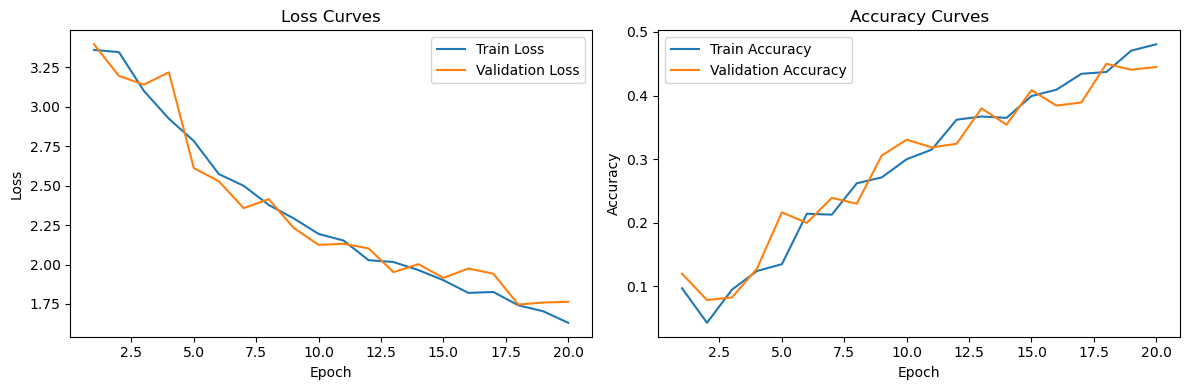

In [9]:
# 3. Bootstrapping
bootstrapped_indices = resample(range(len(dataset)), replace=True, n_samples=len(dataset), random_state=SEED)
train_dataset_bootstrap = RESISC45(Subset(dataset, bootstrapped_indices), transform=train_transform)
test_dataset_bootstrap = RESISC45(dataset, transform=test_transform)  # For bootstrapping, the test set remains the same


# Visualize sample images
fig, axs = plt.subplots(1, 5, figsize=(20, 5))
for i, ax in enumerate(axs):
    idx = random.randint(0, len(train_dataset_bootstrap) - 1)  # Adjusted here
    img, label = train_dataset_bootstrap[idx]
    ax.imshow(img.permute(1, 2, 0))
    ax.set_title(dataset.classes[label])
    ax.axis('off')
plt.show()

# Print the counts of images for each class in the training and testing sets
train_class_counts = {c: 0 for c in dataset.classes}
test_class_counts = {c: 0 for c in dataset.classes}

for img, label in train_dataset_bootstrap:
    train_class_counts[dataset.classes[label]] += 1

for img, label in test_dataset_bootstrap:
    test_class_counts[dataset.classes[label]] += 1

print("Training Set:")
for class_name, count in train_class_counts.items():
    print(f"Class '{class_name}': {count} images")

print("\nTesting Set:")
for class_name, count in test_class_counts.items():
    print(f"Class '{class_name}': {count} images")

# Train and save the model
model_path = os.path.join(model_dir, 'bootstrap_model3.pth')
bootstrap_model, bootstrap_train_accs, bootstrap_test_accs, bootstrap_train_losses, bootstrap_test_losses = train_and_save_model(train_dataset_bootstrap, test_dataset_bootstrap, model_path)

Performance Metrics Table:
                                          Accuracy      Loss
Holdout                                   0.167857  2.780631
K-fold         tensor(0.2071, dtype=torch.float64)  2.637036
Bootstrapping                                0.445  1.763731


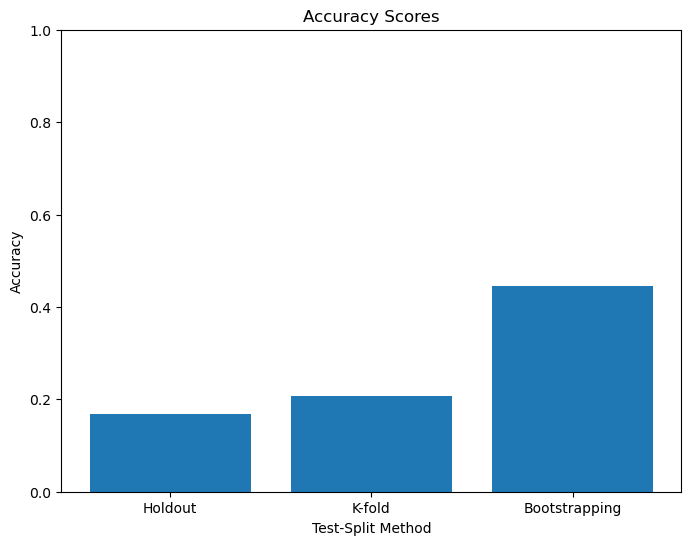

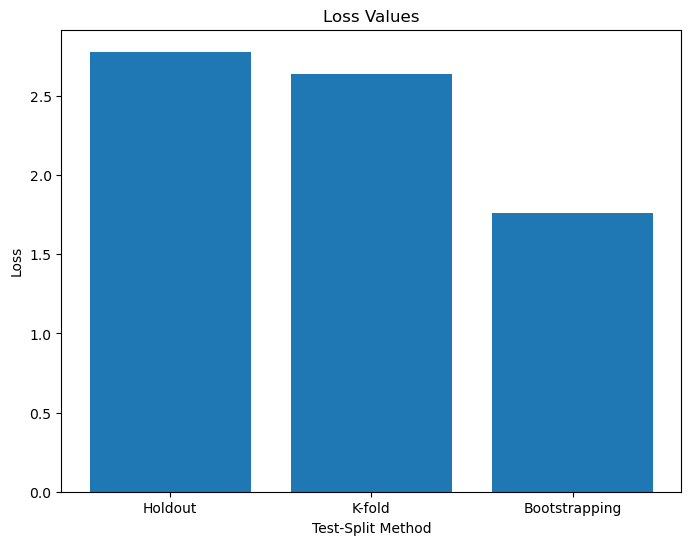

In [14]:
# Performance comparison
performance_metrics = {
    'Holdout': {'Accuracy': 0.0, 'Loss': 0.0},
    'K-fold': {'Accuracy': 0.0, 'Loss': 0.0},
    'Bootstrapping': {'Accuracy': 0.0, 'Loss': 0.0}
}

# Holdout method
performance_metrics['Holdout']['Accuracy'] = holdout_test_accs[-1].item()
performance_metrics['Holdout']['Loss'] = holdout_test_losses[-1]

# K-fold Cross-Validation
performance_metrics['K-fold']['Accuracy'] = mean_kfold_accuracy
performance_metrics['K-fold']['Loss'] = mean_kfold_loss

# Bootstrapping
bootstrap_test_acc = bootstrap_test_accs[-1].item()
bootstrap_test_loss = bootstrap_test_losses[-1]
performance_metrics['Bootstrapping']['Accuracy'] = bootstrap_test_acc
performance_metrics['Bootstrapping']['Loss'] = bootstrap_test_loss


# Create a table to display the performance metrics
metrics_df = pd.DataFrame(performance_metrics).T
print("Performance Metrics Table:")
print(metrics_df)

# Create a bar graph to visualize the accuracy scores
plt.figure(figsize=(8, 6))
plt.bar(metrics_df.index, metrics_df['Accuracy'])
plt.title('Accuracy Scores')
plt.xlabel('Test-Split Method')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.show()

# Create a bar graph to visualize the loss values
plt.figure(figsize=(8, 6))
plt.bar(metrics_df.index, metrics_df['Loss'])
plt.title('Loss Values')
plt.xlabel('Test-Split Method')
plt.ylabel('Loss')
plt.show()

In [11]:
def train_model(model_name, train_dataset, test_dataset, num_classes, model_path, architecture='finetuned', pretrained=True):    # Initialize the model
    if model_name == 'resnet18':
        model = models.resnet18(pretrained=pretrained)
        num_ftrs = model.fc.in_features
        model.fc = nn.Linear(num_ftrs, num_classes)
    elif model_name == 'densenet169':
        model = models.densenet169(pretrained=pretrained)
        num_ftrs = model.classifier.in_features
        model.classifier = nn.Linear(num_ftrs, num_classes)
    elif model_name == 'mobilenetv2':
        model = models.mobilenet_v2(pretrained=pretrained)
        num_ftrs = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(num_ftrs, num_classes)
    elif model_name == 'resnext101_32x8d':
        model = models.resnext101_32x8d(pretrained=pretrained)
        num_ftrs = model.fc.in_features
        model.fc = nn.Linear(num_ftrs, num_classes)
    else:
        raise ValueError(f"Invalid model name: {model_name}")

    
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()

    if architecture == 'fixed_feature_extractor':
        # Freeze all layers first
        for param in model.parameters():
            param.requires_grad = False

    # Then unfreeze the last layer(s)
    if model_name == 'resnet18':
        model.fc.weight.requires_grad = True
        model.fc.bias.requires_grad = True
    elif model_name == 'densenet169':
        model.classifier.weight.requires_grad = True
        model.classifier.bias.requires_grad = True
    elif model_name == 'mobilenetv2':
        model.classifier[1].weight.requires_grad = True
        model.classifier[1].bias.requires_grad = True
    elif model_name == 'resnext101_32x8d':
        model.fc.weight.requires_grad = True
        model.fc.bias.requires_grad = True
    # Create a new optimizer for the unfrozen parameters
    unfrozen_parameters = [param for param in model.parameters() if param.requires_grad]
    optimizer = torch.optim.Adam(unfrozen_parameters, lr=0.001)

    scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=5, verbose=True)
    
    # Train the model
    num_epochs = 20
    batch_size = 5
    train_losses, train_accs = [], []
    test_losses, test_accs = [], []

    for epoch in range(num_epochs):
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

        train_epoch_loss, train_epoch_acc = train_epoch(train_dataset, model, criterion, optimizer, batch_size, device)
        test_epoch_loss, test_epoch_acc = eval_model(test_dataset, model, criterion, batch_size, device, accuracy)

        scheduler.step(test_epoch_loss)

        train_losses.append(train_epoch_loss)
        train_accs.append(train_epoch_acc)
        test_losses.append(test_epoch_loss)
        test_accs.append(test_epoch_acc)

        print(f'Epoch {epoch + 1}/{num_epochs} Train Loss: {train_epoch_loss:.4f} Train Acc: {train_epoch_acc:.4f} Test Loss: {test_epoch_loss:.4f} Test Acc: {test_epoch_acc:.4f}')

    # Save the trained model
    torch.save(model.state_dict(), model_path)

    return train_accs, test_accs, train_losses, test_losses

def train_epoch(dataset, model, criterion, optimizer, batch_size, device):
    model.train()
    train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    running_loss = 0.0
    running_acc = 0.0

    pbar = tqdm(train_loader, desc="Training", leave=True)  # Initialize tqdm progress bar
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        acc = accuracy(outputs, labels)
        running_acc += acc * inputs.size(0)
        
        pbar.set_description(f"Training Loss: {loss.item():.4f}, Accuracy: {acc.item():.4f}")  # Update progress bar

    epoch_loss = running_loss / len(dataset)
    epoch_acc = running_acc / len(dataset)

    return epoch_loss, epoch_acc

def eval_model(dataset, model, criterion, batch_size, device, metric_fn):
    model.eval()
    eval_loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    running_loss = 0.0
    running_metric = 0.0

    pbar = tqdm(eval_loader, desc="Evaluating", leave=True)  # Initialize tqdm progress bar
    with torch.no_grad():
        for inputs, labels in pbar:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            metric = metric_fn(outputs, labels)
            running_metric += metric * inputs.size(0)
            
            pbar.set_description(f"Evaluating Loss: {loss.item():.4f}, Metric: {metric.item():.4f}")  # Update progress bar

    epoch_loss = running_loss / len(dataset)
    epoch_metric = running_metric / len(dataset)

    return epoch_loss, epoch_metric


Training resnet18 (finetuned)


/Users/shiwaditya./anaconda3/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


Training:   0%|          | 0/224 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/56 [00:00<?, ?it/s]

Epoch 1/20 Train Loss: 3.4036 Train Acc: 0.0911 Test Loss: 3.6959 Test Acc: 0.1179


...

Evaluating:   0%|          | 0/56 [00:00<?, ?it/s]

Epoch 19/20 Train Loss: 2.2008 Train Acc: 0.3366 Test Loss: 2.7120 Test Acc: 0.3321


Training:   0%|          | 0/224 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/56 [00:00<?, ?it/s]

Epoch 20/20 Train Loss: 2.1317 Train Acc: 0.3589 Test Loss: 2.7743 Test Acc: 0.3929


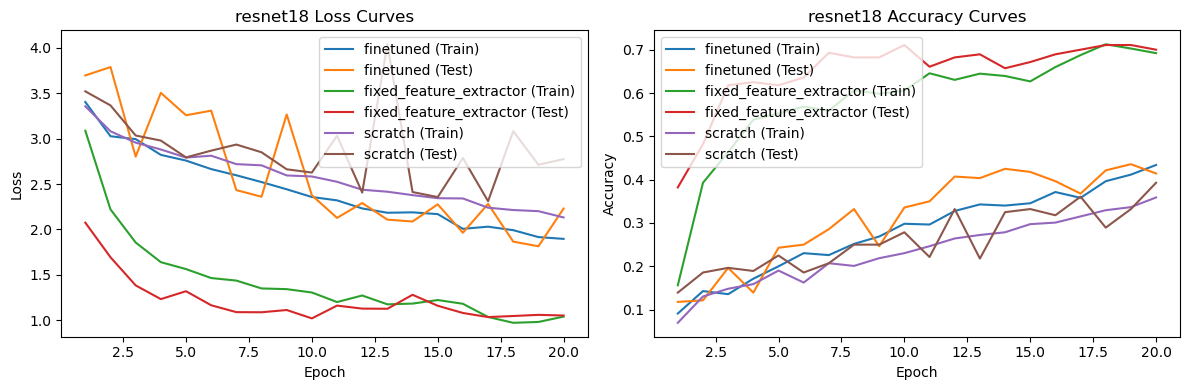

Training densenet169 (finetuned)


/Users/shiwaditya./anaconda3/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet169_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet169_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Training:   0%|          | 0/224 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/56 [00:00<?, ?it/s]

Epoch 1/20 Train Loss: 3.4059 Train Acc: 0.0884 Test Loss: 4.1707 Test Acc: 0.1679


...

Evaluating:   0%|          | 0/56 [00:00<?, ?it/s]

Epoch 19/20 Train Loss: 2.1207 Train Acc: 0.3661 Test Loss: 13.1840 Test Acc: 0.3786


Training:   0%|          | 0/224 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/56 [00:00<?, ?it/s]

Epoch 20/20 Train Loss: 2.1241 Train Acc: 0.3464 Test Loss: 17.0770 Test Acc: 0.3250


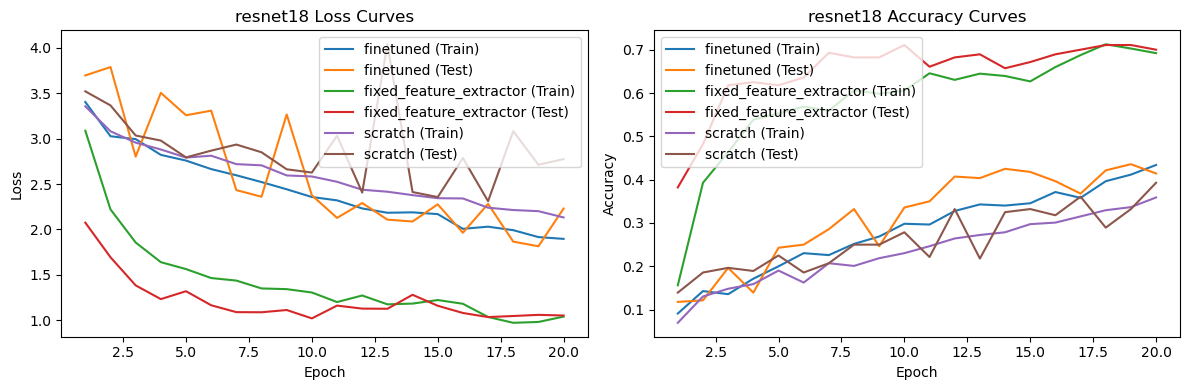

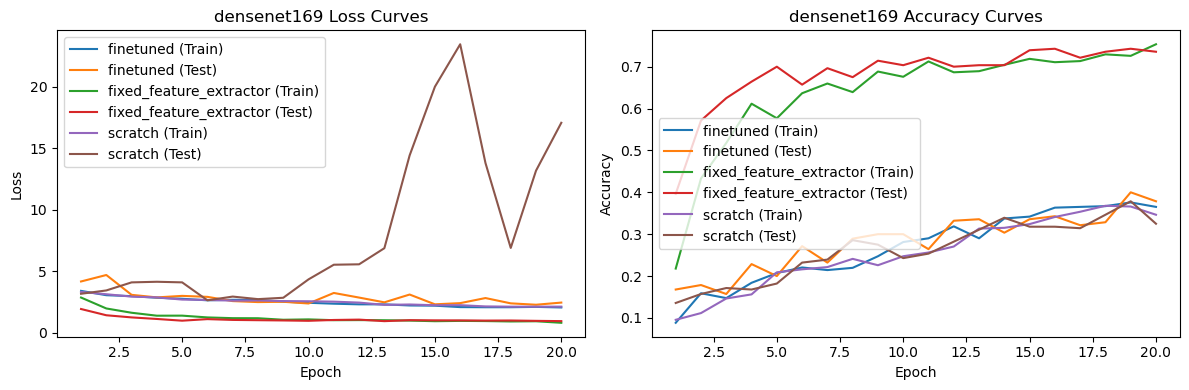

Training mobilenetv2 (finetuned)


/Users/shiwaditya./anaconda3/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Training:   0%|          | 0/224 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/56 [00:00<?, ?it/s]

Epoch 1/20 Train Loss: 3.2654 Train Acc: 0.1259 Test Loss: 2.5672 Test Acc: 0.2000


...

Evaluating:   0%|          | 0/56 [00:00<?, ?it/s]

Epoch 19/20 Train Loss: 2.3420 Train Acc: 0.3080 Test Loss: 2.1695 Test Acc: 0.3286


Training:   0%|          | 0/224 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/56 [00:00<?, ?it/s]

Epoch 20/20 Train Loss: 2.3303 Train Acc: 0.2973 Test Loss: 2.2249 Test Acc: 0.3321


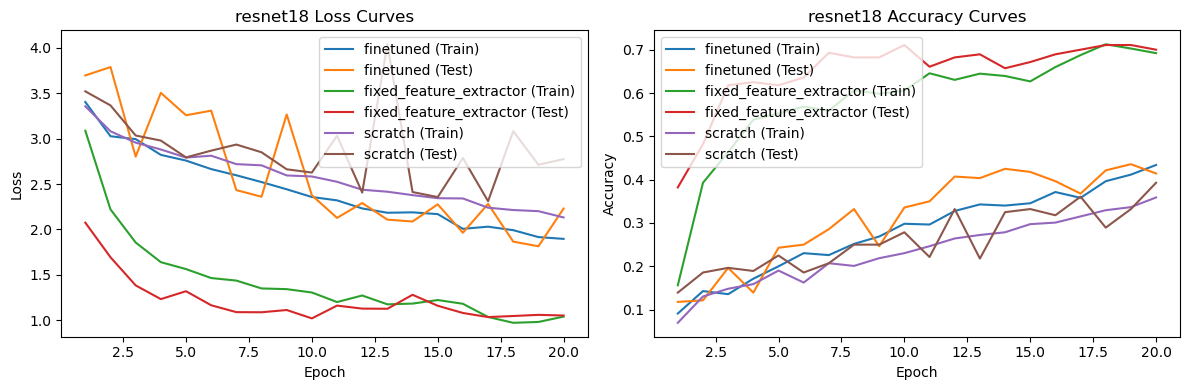

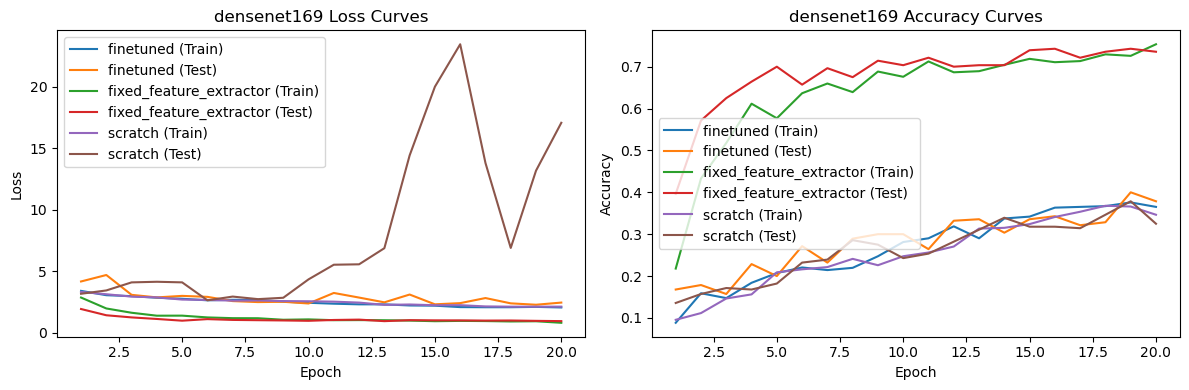

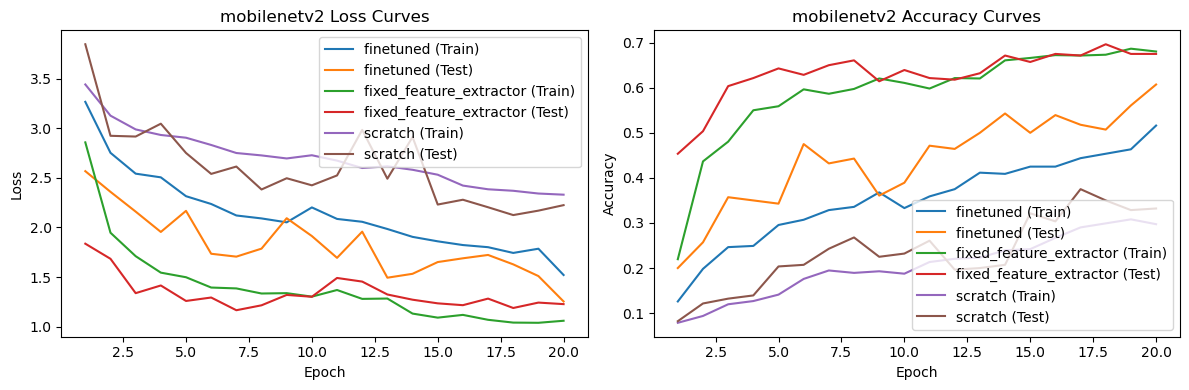

Training resnext101_32x8d (finetuned)


/Users/shiwaditya./anaconda3/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNeXt101_32X8D_Weights.IMAGENET1K_V1`. You can also use `weights=ResNeXt101_32X8D_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Training:   0%|          | 0/224 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/56 [00:00<?, ?it/s]

Epoch 1/20 Train Loss: 3.5167 Train Acc: 0.0429 Test Loss: 4.5700 Test Acc: 0.0679


...

Evaluating:   0%|          | 0/56 [00:00<?, ?it/s]

Epoch 19/20 Train Loss: 2.4324 Train Acc: 0.2616 Test Loss: 2.5377 Test Acc: 0.2821


Training:   0%|          | 0/224 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/56 [00:00<?, ?it/s]

Epoch 20/20 Train Loss: 2.3962 Train Acc: 0.2812 Test Loss: 2.3998 Test Acc: 0.2714


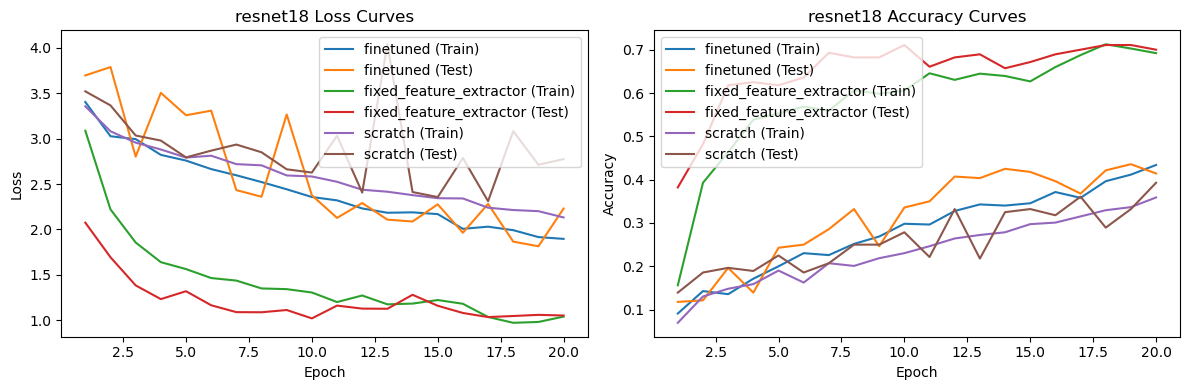

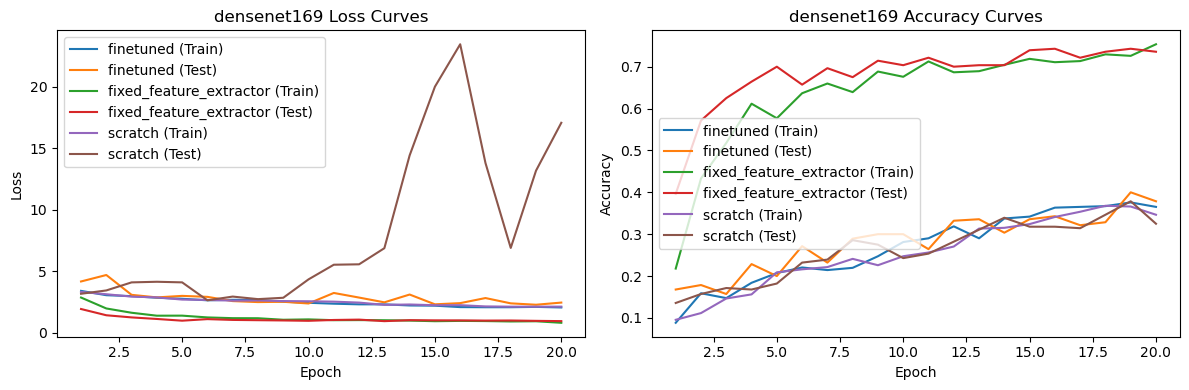

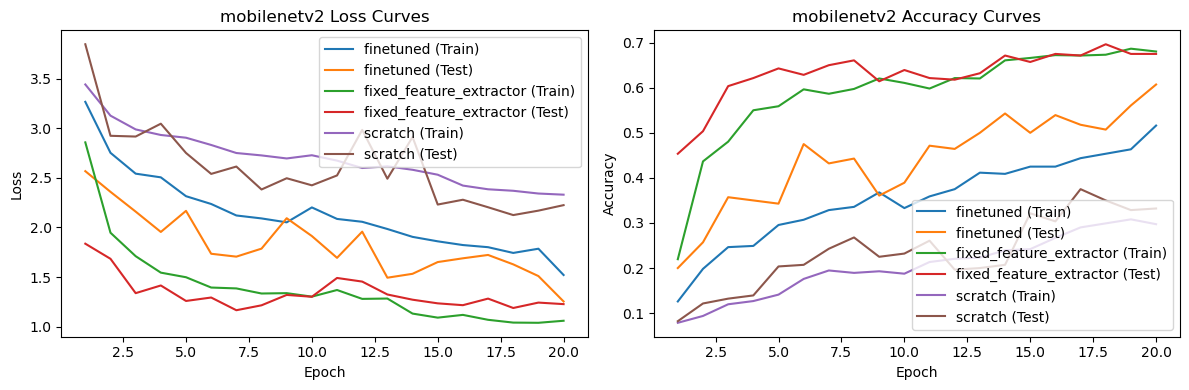

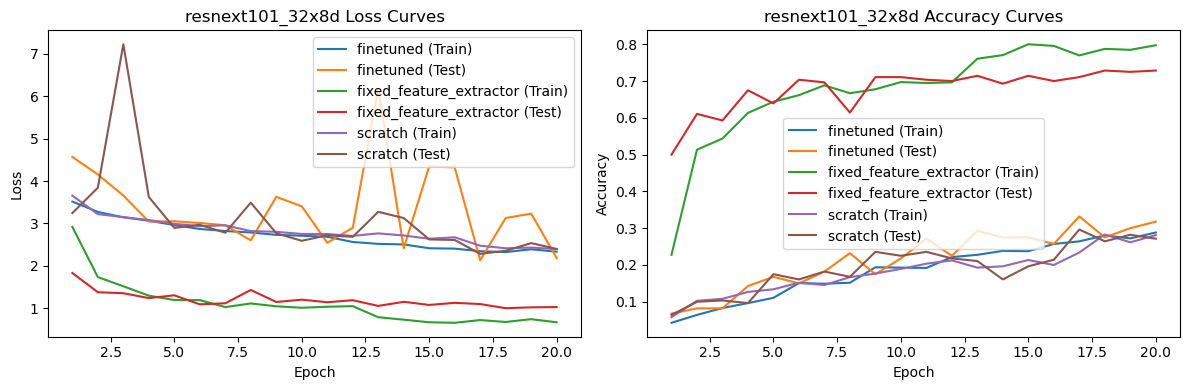

Model: resnet18
Architecture: finetuned
Final Train Accuracy: 0.4339
Final Test Accuracy: 0.4143
Final Train Loss: 1.8956
Final Test Loss: 2.2294

Architecture: fixed_feature_extractor
Final Train Accuracy: 0.6920
Final Test Accuracy: 0.7000
Final Train Loss: 1.0393
Final Test Loss: 1.0516

Architecture: scratch
Final Train Accuracy: 0.3589
Final Test Accuracy: 0.3929
Final Train Loss: 2.1317
Final Test Loss: 2.7743

Model: densenet169
Architecture: finetuned
Final Train Accuracy: 0.3652
Final Test Accuracy: 0.3786
Final Train Loss: 2.0575
Final Test Loss: 2.4532

Architecture: fixed_feature_extractor
Final Train Accuracy: 0.7536
Final Test Accuracy: 0.7357
Final Train Loss: 0.8096
Final Test Loss: 0.9456

Architecture: scratch
Final Train Accuracy: 0.3464
Final Test Accuracy: 0.3250
Final Train Loss: 2.1241
Final Test Loss: 17.0770

Model: mobilenetv2
Architecture: finetuned
Final Train Accuracy: 0.5161
Final Test Accuracy: 0.6071
Final Train Loss: 1.5211
Final Test Loss: 1.2546

Arch

In [12]:
# Create the directory if it doesn't exist
model_dir = 'MODELS'
os.makedirs(model_dir, exist_ok=True)
# Train and evaluate the models for different architectures
model_names = ['resnet18', 'densenet169', 'mobilenetv2', 'resnext101_32x8d']
architectures = ['finetuned', 'fixed_feature_extractor', 'scratch']

results = {}

for model_name in model_names:
    results[model_name] = {}
    for architecture in architectures:
        print(f"Training {model_name} ({architecture})")
        model_path = os.path.join(model_dir, f"{model_name}_{architecture}_3.pth")
        if architecture == 'scratch':
            pretrained = False
        else:
            pretrained = True

        train_accs, test_accs, train_losses, test_losses = train_model(
            model_name, train_dataset, test_dataset, len(class_names), model_path, architecture, pretrained
        )

        results[model_name][architecture] = {
            'train_acc': train_accs,
            'test_acc': test_accs,
            'train_loss': train_losses,
            'test_loss': test_losses
        }

    # Visualize the results
    for model_name, model_results in results.items():
        fig, axs = plt.subplots(1, 2, figsize=(12, 4))

        for architecture, arch_results in model_results.items():
            axs[0].plot(range(1, len(arch_results['train_loss']) + 1), arch_results['train_loss'], label=f"{architecture} (Train)")
            axs[0].plot(range(1, len(arch_results['test_loss']) + 1), arch_results['test_loss'], label=f"{architecture} (Test)")
        axs[0].set_title(f'{model_name} Loss Curves')
        axs[0].set_xlabel('Epoch')
        axs[0].set_ylabel('Loss')
        axs[0].legend()

        for architecture, arch_results in model_results.items():
            axs[1].plot(range(1, len(arch_results['train_acc']) + 1), arch_results['train_acc'], label=f"{architecture} (Train)")
            axs[1].plot(range(1, len(arch_results['test_acc']) + 1), arch_results['test_acc'], label=f"{architecture} (Test)")
        axs[1].set_title(f'{model_name} Accuracy Curves')
        axs[1].set_xlabel('Epoch')
        axs[1].set_ylabel('Accuracy')
        axs[1].legend()

        plt.tight_layout()
        plt.show()

# Print the final performance metrics
for model_name, model_results in results.items():
    print(f"Model: {model_name}")
    for architecture, arch_results in model_results.items():
        print(f"Architecture: {architecture}")
        print(f"Final Train Accuracy: {arch_results['train_acc'][-1]:.4f}")
        print(f"Final Test Accuracy: {arch_results['test_acc'][-1]:.4f}")
        print(f"Final Train Loss: {arch_results['train_loss'][-1]:.4f}")
        print(f"Final Test Loss: {arch_results['test_loss'][-1]:.4f}")
        print()
